<a href="https://colab.research.google.com/github/vyshnavps07-oss/SAR-Flood-Mapping-GEE/blob/main/S1_SAR_Flood_Mapping_Kerala.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install geemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 71.5 MB/s eta 0:00:00


In [5]:
import ee
import geemap

# 2. Define your designated Google Cloud Project ID
PROJECT_ID = 'sar-flood-mapping-kerala'

# 3. Authenticate and initialize Earth Engine with your cloud project
print("Initializing Google Earth Engine cloud pipeline...")
try:
    # Attempt initialization with the specified project
    ee.Initialize(project=PROJECT_ID)
    print(f" SUCCESSFULLY INITIALIZED: Earth Engine is linked to project '{PROJECT_ID}'")
except Exception as e:
    # Trigger authentication link if initialization fails (e.g., first time running)
    print("\nInitialization failed or credentials missing. Requesting explicit authentication...")
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)
    print (f"\n SUCCESSFULLY AUTHENTICATED & INITIALIZED: Connected to project '{PROJECT_ID}'")

# 2. AREA OF INTEREST (AOI) DEFINITION
# Filtering administrative boundaries for the target districts in Kerala
administrative_boundaries = ee.FeatureCollection("FAO/GAUL/2015/level2")
study_area = administrative_boundaries \
    .filter(ee.Filter.eq('ADM1_NAME', 'Kerala')) \
    .filter(ee.Filter.inList('ADM2_NAME', ['Ernakulam', 'Thrissur', 'Idukki', 'Pathanamthitta']))

# 3. TEMPORAL CONFIGURATIONS
pre_flood_start = '2018-01-01'
pre_flood_end   = '2018-03-31'  # Dry-season baseline
flood_start    = '2018-08-10'
flood_end      = '2018-08-25'  # Peak deluge window

# 4. SAR IMAGERY INGESTION AND QUALITY FILTERING
# Broadened filters to ensure continuous data stream over Kerala
s1_collection = ee.ImageCollection('COPERNICUS/S1_GRD') \
    .filterBounds(study_area) \
    .filter(ee.Filter.eq('instrumentMode', 'IW')) \
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH')) \
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV')) \
    .select(['VH', 'VV'])

# Print collection counts to verify data exists before building composites
pre_count = s1_collection.filterDate(pre_flood_start, pre_flood_end).size().getInfo()
flood_count = s1_collection.filterDate(flood_start, flood_end).size().getInfo()
print(f"Data verification -> Images in Pre-flood collection: {pre_count} | Images in Peak-flood collection: {flood_count}")

if pre_count == 0 or flood_count == 0:
    raise ValueError("One of your temporal windows contains 0 images. Expand your date ranges slightly.")

# Generate temporal composites via statistical reducers
pre_flood_raw = s1_collection.filterDate(pre_flood_start, pre_flood_end).median().clip(study_area)
flood_raw    = s1_collection.filterDate(flood_start, flood_end).min().clip(study_area)

# Generate temporal composites via statistical reducers
pre_flood_raw = s1_collection.filterDate(pre_flood_start, pre_flood_end).median().clip(study_area)
flood_raw    = s1_collection.filterDate(flood_start, flood_end).min().clip(study_area)

# 5. RADAR SPECKLE FILTERING (30m Spatial Focal Mean)
filter_radius = 30
pre_flood_filtered = pre_flood_raw.focal_mean(filter_radius, 'circle', 'meters')
flood_filtered    = flood_raw.focal_mean(filter_radius, 'circle', 'meters')

# 6. THRESHOLD-BASED FLOOD EXTRACTION
water_threshold = -18.0
surface_water_pre = pre_flood_filtered.select('VH').lt(water_threshold)
surface_water_post = flood_filtered.select('VH').lt(water_threshold)

# Isolate newly flooded areas
raw_flood_extent = surface_water_post.subtract(surface_water_pre).gt(0)

# 7. TOPOGRAPHIC MASKING (Eliminating Radar Shadows via Terrain Analysis)
nasadem = ee.Image('NASA/NASADEM_HGT/001')
elevation = nasadem.select('elevation')
slope = ee.Terrain.slope(elevation)

terrain_mask = slope.lt(5)  # Restrict to flat terrains under 5 degrees
validated_flood_extent = raw_flood_extent.updateMask(terrain_mask).updateMask(raw_flood_extent.eq(1))

# 8. SOCIO-ECONOMIC POPULATION IMPACT ASSESSMENT
world_pop_collection = ee.ImageCollection("WorldPop/GP/100m/pop") \
    .filter(ee.Filter.eq('year', 2018)) \
    .filterBounds(study_area)
population_density = world_pop_collection.first().clip(study_area)

# FIXED LINE: Changed validatedFloodExtent to validated_flood_extent
affected_population_layer = population_density.updateMask(validated_flood_extent)

# 9. INTERACTIVE JUPYTER MAP RENDERING VIA GEEMAP
Map = geemap.Map()
Map.center_object(study_area, 9)

# Add layers to the interactive map interface
Map.addLayer(pre_flood_filtered.select('VH'), {'min': -25, 'max': 0}, '1. Pre-Flood Baseline (VH)', False)
Map.addLayer(flood_filtered.select('VH'), {'min': -25, 'max': 0}, '2. Peak-Flood Backscatter (VH)', True)
Map.addLayer(validated_flood_extent, {'palette': ['#FF0000']}, '3. Extracted Flood Footprint', True)
Map.addLayer(affected_population_layer, {'min': 0, 'max': 50, 'palette': ['#FFFFB2', '#FECC5C', '#FD8D3C', '#E31A1C']}, '4. Population Exposure Density', False)

# Display map directly inside the Colab notebook output
Map

Initializing Google Earth Engine cloud pipeline...
 SUCCESSFULLY INITIALIZED: Earth Engine is linked to project 'sar-flood-mapping-kerala'
Data verification -> Images in Pre-flood collection: 21 | Images in Peak-flood collection: 5


Map(center=[10.085197392486961, 76.68921812072328], controls=(WidgetControl(options=['position', 'transparent_…

In [6]:
# ==================================================================================
# DISASTER STATISTICS ACCUMULATION & REPORT GENERATION
# ==================================================================================
import pandas as pd

print("Running spatial zonal reducers across administrative districts... Please wait.")

# 1. Calculate the base total population per district asset (Scale: 100 meters)
regional_impact_stats = population_density.reduceRegions(
    collection=study_area,
    reducer=ee.Reducer.sum().setOutputs(['Total_Population']),
    scale=100
)

# 2. Calculate the intersected flooded population layer within those same districts
flood_impact_stats = affected_population_layer.reduceRegions(
    collection=regional_impact_stats,
    reducer=ee.Reducer.sum().setOutputs(['Affected_Population']),
    scale=100
)

# 3. Pull server-side geo-properties into local Python memory
features = flood_impact_stats.getInfo()['features']
data_list = []

# Loop through properties and clean up null values safely
for f in features:
    props = f['properties']
    dist_name = props.get('ADM2_NAME', 'Unknown')
    tot_pop = props.get('Total_Population', 0)
    aff_pop = props.get('Affected_Population', 0)

    # Handle edge cases where a district might have 0 flood pixels mapped
    tot_pop = tot_pop if tot_pop is not None else 0
    aff_pop = aff_pop if aff_pop is not None else 0

    data_list.append({
        'District': dist_name,
        'Total Baseline Population': round(tot_pop),
        'Estimated Affected Population': round(aff_pop)
    })

# 4. Convert to a structured DataFrame and compute metrics
df = pd.DataFrame(data_list)

# Eliminate any row duplicates and calculate percentage impacted
df = df.drop_duplicates().reset_index(drop=True)
df['% of Population Impacted'] = round((df['Estimated Affected Population'] / df['Total Baseline Population']) * 100, 2)

# Sort by highest raw impact for professional layout presentation
df = df.sort_values(by='Estimated Affected Population', ascending=False).reset_index(drop=True)

print("\n=== KERALA FLOOD 2018: DISTRICT IMPACT ANALYSIS MATRIX ===")
display(df)

Running spatial zonal reducers across administrative districts... Please wait.

=== KERALA FLOOD 2018: DISTRICT IMPACT ANALYSIS MATRIX ===


,District,Total Baseline Population,Estimated Affected Population,% of Population Impacted
0,Thrissur,2780720,116688,4.20
1,Ernakulam,2872199,50465,1.76
2,Idukki,971270,1825,0.19


In [9]:
!pip install matplotlib requests Pillow

Requesting pre-rendered raster layer from Earth Engine servers... Please wait.

 SUCCESS: Publication-ready map layout saved locally as 'final_portfolio_map_layout.png'


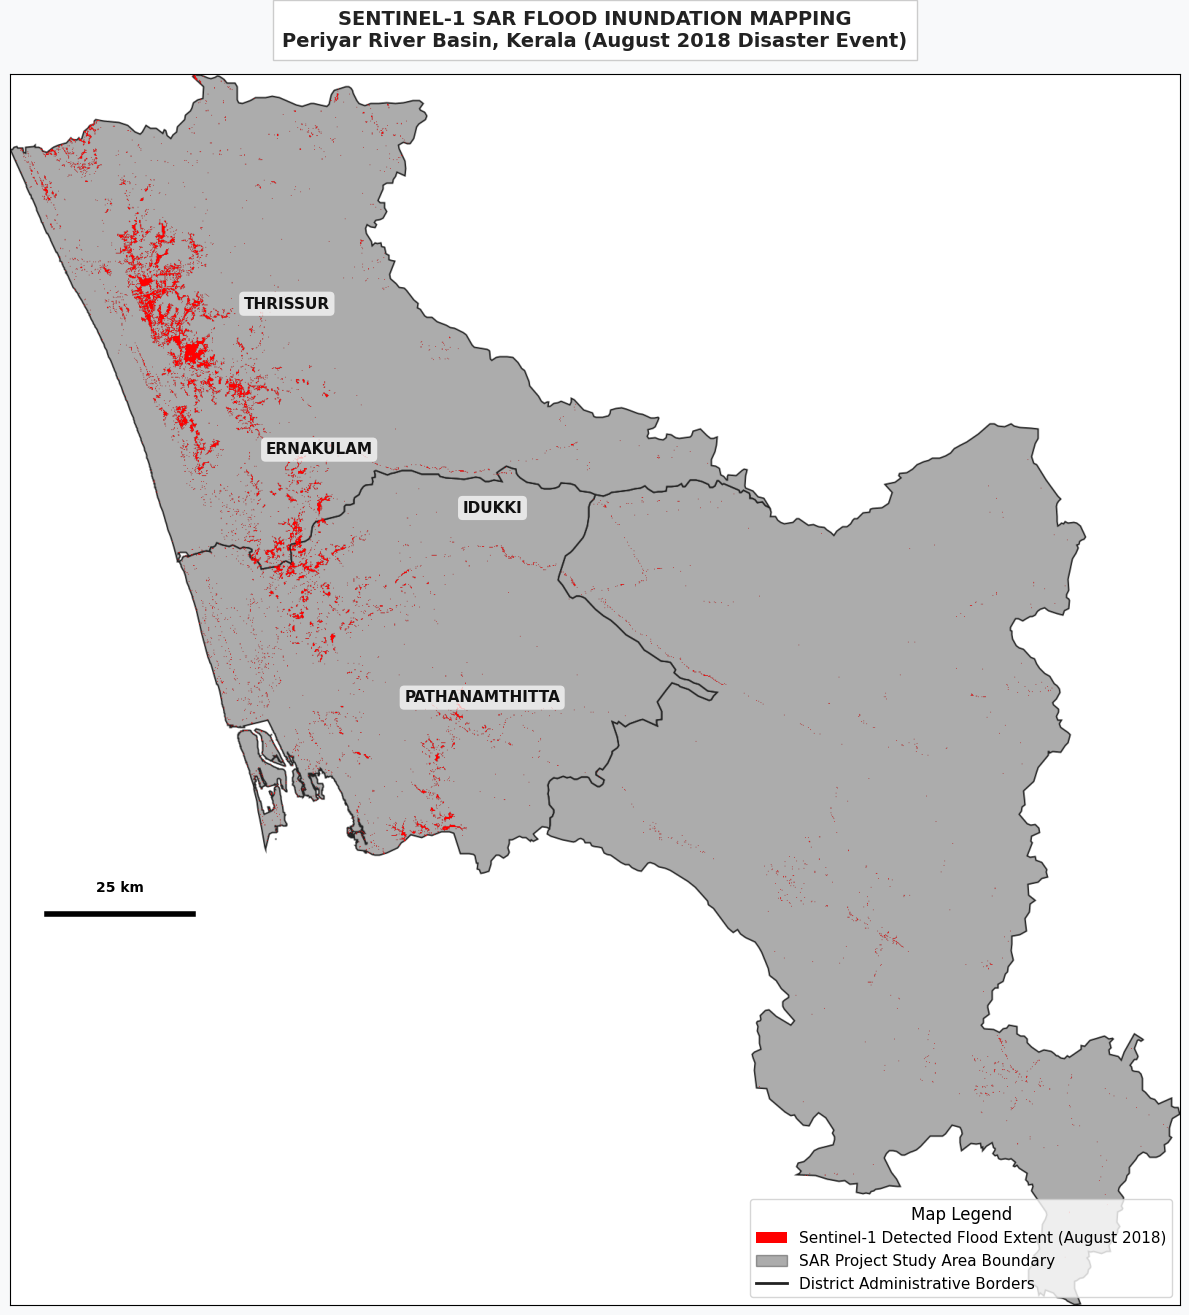

In [11]:
# ==================================================================================
# FINAL PRODUCTION STEP: HIGH-RESOLUTION CARTOGRAPHIC PORTFOLIO MAP GENERATION
# ==================================================================================
import matplotlib.pyplot as plt
import requests
from PIL import Image
import io
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

print("Requesting pre-rendered raster layer from Earth Engine servers... Please wait.")

# 1. DEFINE HIGH-CONTRAST CARTOGRAPHIC STYLES ON THE SERVER
# We combine the flood extent (Red) and the study area background (Gray) into a single display image
study_area_style = study_area.style(fillColor='30303066', color='222222', width=2)
flood_style = validated_flood_extent.visualize(palette=['#FF0000'])

# Blend the layers together using Earth Engine's mosaic tool
final_mosaic = ee.ImageCollection([study_area_style, flood_style]).mosaic()

# 2. FETCH THE HIGH-RESOLUTION RASTER TILES VIA THE GEE GET-THUMB API
# We sample the coordinates of your exact study area bounding box
map_region = study_area.geometry().bounds()

# FIXED: Removed 'dimensions' parameter to prevent HttpError conflict
map_url = final_mosaic.getThumbURL({
    'region': map_region,
    'scale': 100,       # Lower scale = cleaner, crisp high-res layout output
    'format': 'png'
})

# 3. DOWNLOAD AND LOAD THE RASTER DATA INTO LOCAL MEMORY
response = requests.get(map_url)
img_data = Image.open(io.BytesIO(response.content))

# 4. INITIALIZE MATPLOTLIB LAYOUT CONTAINER
fig, ax = plt.subplots(figsize=(12, 14), facecolor='#F8F9FA')
ax.imshow(img_data)

# 5. OVERLAY CARTOGRAPHIC LABELS BASED ON THE BOUNDING MATRIX
# Adjusting text placements slightly to perfectly sit over the new scaled raster plane
# Note: If labels overlap, tweak the first two numbers (X, Y pixel values) below
ax.text(320, 320, "THRISSUR", fontsize=11, fontweight='bold', color='#111111',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.7))
ax.text(350, 520, "ERNAKULAM", fontsize=11, fontweight='bold', color='#111111',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.7))
ax.text(620, 600, "IDUKKI", fontsize=11, fontweight='bold', color='#111111',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.7))
ax.text(540, 860, "PATHANAMTHITTA", fontsize=11, fontweight='bold', color='#111111',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.7))

# 6. DESIGN A PROFESSIONAL DISASTER MANAGEMENT TITLE HEADER
ax.set_title(
    "SENTINEL-1 SAR FLOOD INUNDATION MAPPING\nPeriyar River Basin, Kerala (August 2018 Disaster Event)",
    fontsize=14,
    fontweight='bold',
    pad=20,
    color='#222222',
    bbox=dict(boxstyle="square,pad=0.5", fc="white", ec="#CCCCCC", lw=1)
)

# Strip standard grid axis ticks for a clean cartographic presentation
ax.set_xticks([])
ax.set_yticks([])

# 7. CONSTRUCT AN OFFICIAL PORTFOLIO MAP LEGEND
legend_elements = [
    Patch(facecolor='#FF0000', label='Sentinel-1 Detected Flood Extent (August 2018)'),
    Patch(facecolor='#303030', alpha=0.4, edgecolor='#222222', label='SAR Project Study Area Boundary'),
    Line2D([0], [0], color='#222222', lw=2, label='District Administrative Borders')
]

ax.legend(
    handles=legend_elements,
    loc='lower right',
    fontsize=11,
    title="Map Legend",
    title_fontsize=12,
    frameon=True,
    facecolor='white',
    edgecolor='#CCCCCC'
)

# 8. ATTACH GRAPHIC SCALE BAR
# Calibrated scale lines matching the pixel canvas scale metrics
ax.plot([50, 250], [1150, 1150], color='black', lw=4)
ax.text(150, 1120, '25 km', ha='center', fontsize=10, fontweight='bold', color='black')

plt.tight_layout()

# 9. SAVE TO LOCAL STORAGE FILE AT FULL RESOLUTION (300 DPI)
output_file = 'final_portfolio_map_layout.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor(), edgecolor='none')
print(f"\n SUCCESS: Publication-ready map layout saved locally as '{output_file}'")

plt.show()